In [69]:
import numpy as np
import math
import matplotlib.pyplot as plt


In [70]:
# Naturkonstanten
m = g = l = 1


In [71]:
# EEV Parameter
# Schrittweite

T = 10000
h = 0.01              
N = int(T / h)        

In [72]:
# Startwerte

a = np.zeros(N+1)
w = np.zeros(N+1)

a[0] = math.pi / 4
w[0] = 0

for i in range(0, N):
    a[i+1] = a[i] + h * w[i]
    w[i+1] = w[i] + h * (- (g / l) * np.sin(a[i]))


Text(0.5, 1.0, 'Phasenraum')

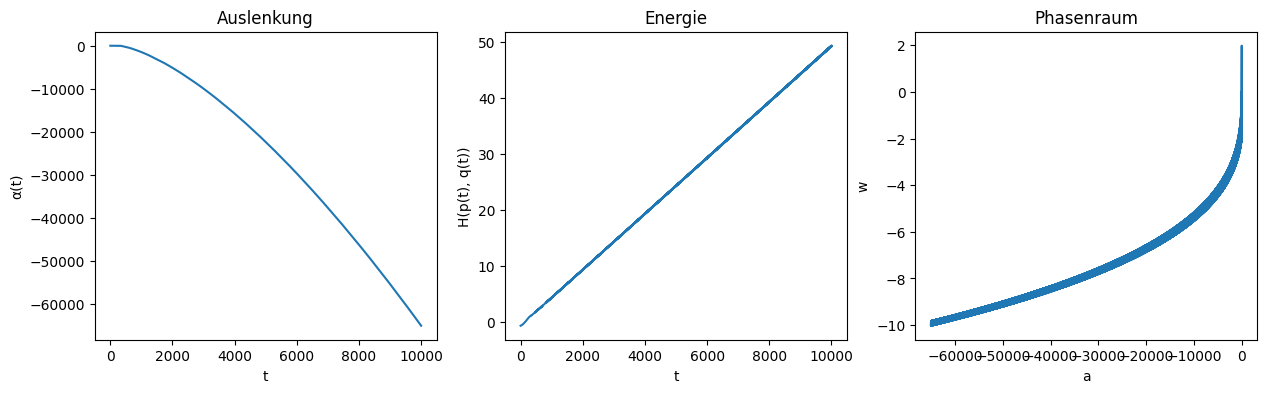

In [73]:
def H(a, w):
    return -np.cos(a) + 0.5 * w**2


# Plotten
t = np.linspace(0, T, N+1)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, a)
axes[0].set_xlabel("t")
axes[0].set_ylabel("α(t)")
axes[0].set_title("Auslenkung")

axes[1].plot(t, H(a, w))
axes[1].set_xlabel("t")
axes[1].set_ylabel("H(p(t), q(t))")
axes[1].set_title("Energie")

axes[2].plot(a, w)
axes[2].set_xlabel("a")
axes[2].set_ylabel("w")
axes[2].set_title("Phasenraum")

In [74]:
# Startwerte

a = np.zeros(N+1)
w = np.zeros(N+1)

a[0] = math.pi / 4
w[0] = 0



Text(0.5, 1.0, 'Phasenraum')

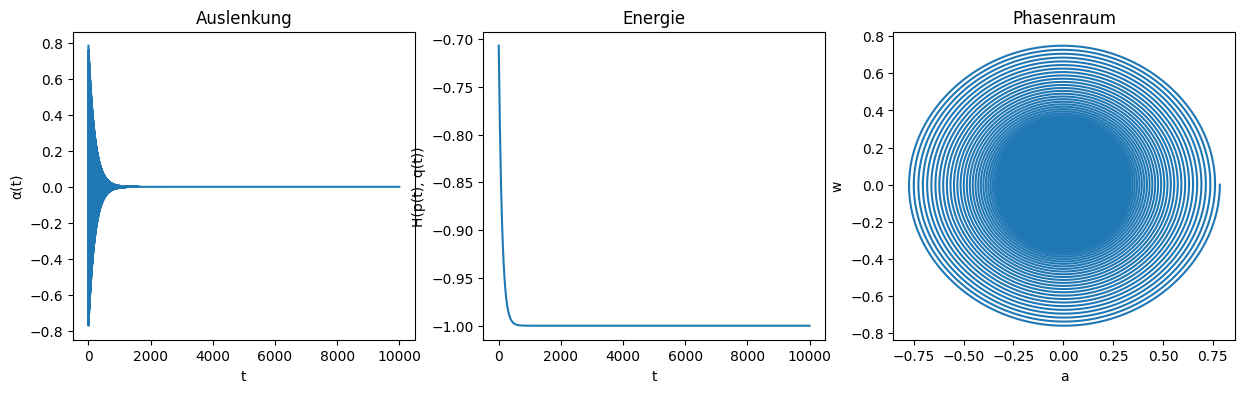

In [ ]:
def f(t, u):
    theta, omega = u
    return np.array([omega, -(g/l) * np.sin(theta)])

def J_f(t, u):
    theta, omega = u
    return np.array([
        [0,              1],
        [-(g/l)*np.cos(theta), 0]
    ])

def newton_step(u_j, t_next, tau, tol=1e-10, max_iter=50):
    u = u_j.copy()

    for _ in range(max_iter):
        F  = u - u_j - tau * f(t_next, u)          # Nullstellenvektor
        dF = np.eye(2) - tau * J_f(t_next, u)      # Jacobi von F

        delta = np.linalg.solve(dF, -F)             # Δu = -[F']⁻¹ · F
        u = u + delta                               # Newton-Update

        if np.linalg.norm(delta) < tol:             # Konvergiert?
            break

    return u
        


u = np.zeros((N+1, 2))   
u[0] = [np.pi/4, 0]      

t = np.linspace(0, T, N+1)

for i in range(N):
    u[i+1] = newton_step(u[i], t_next=t[i+1], tau=h)

a = u[:, 0]   
w = u[:, 1]   

# Plotten
t = np.linspace(0, T, N+1)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, a)
axes[0].set_xlabel("t")
axes[0].set_ylabel("α(t)")
axes[0].set_title("Auslenkung")

axes[1].plot(t, H(a, w))
axes[1].set_xlabel("t")
axes[1].set_ylabel("H(p(t), q(t))")
axes[1].set_title("Energie") 

axes[2].plot(a, w)
axes[2].set_xlabel("a")
axes[2].set_ylabel("w")
axes[2].set_title("Phasenraum")